# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/damlablgc/flyrankinternship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

I rank the client-grouped, held-out test set by the Week-6-audited Random Forest
(precision@50 = 0.540 on this run's held-out 9 clients, base rate 0.373, n=13,210 — in
line with Week 6's 0.56 on a separate audited run; both use the same split logic and
model config, so the small gap is expected run-to-run variance, not a discrepancy).

Each of the top 50 gets an **archetype**, assigned in this priority order:

1. **`low_traffic_uncertain`** (`monitor_only`) — `imp_trailing < 500`. This is a reliability
   gate, not a content signal: at this volume, `is_declining` can flip on a one-impression
   difference (e.g. a page with `imp_trailing=2` crosses its own decline threshold at 1.6
   impressions). **39 of the top 50 rows (78%) fell here** on this run — the model ranks them
   high, largely on `content_age_days` (median ~200 days), but the label backing that ranking
   is too noisy for a specific content action. These are flagged to *watch*, not to *act on*.
2. **`ctr_fade`** (`review_ctr_fix`, reason code `low_ctr_good_position`) — visible
   (`imp_trailing >= 500`), good position (≤20), below-median CTR. Reuses the Week-4 rule,
   the one signal with a directly measured precision gap (34.3% vs 17.5% decline rate,
   n=15,274 vs n=18,954). None of the top 50 matched this pattern on this run — the model's
   highest-confidence rows this month happen to be low-traffic/young content instead.
3. **`young_high_risk`** (`review_new_content_health`, reason code `young_content_elevated_risk`)
   — `content_age_days < 90` and sufficient traffic. 11 of 50 rows, observed precision 0.455
   in this run (n=11 — small sample, directional only, not a stable rate). Ties to the Week-4
   signal audit: content under 90 days showed a higher decline rate than older content
   (21.3% vs 13.9%), the opposite of the naive "old content decays" hypothesis.

**What this queue is not saying:** it is not saying these 50 items *will* decline, and the
`low_traffic_uncertain` share is not evidence the model is broken — it's evidence that ranking
by probability alone, without a traffic floor, surfaces statistically fragile rows first. The
reliability gate exists specifically to stop that from reaching a human as an action item.

In [1]:
from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
MONTH_PATH = f"{REL}/fact_content_daily_performance/month=2026-03/*.parquet"
DECISION_DAY = '2026-03-15'

# Same feature + label query as Week 4/5/6 -- same month, same decision day,
# so this playbook's queue is directly comparable to the audited numbers.
features = con.sql(f"""
    WITH fx AS (
        SELECT
            f.client_hash_id, f.content_hash_id,
            SUM(CASE WHEN f.report_date <= DATE '{DECISION_DAY}' THEN f.gsc_impressions ELSE 0 END) AS imp_trailing,
            SUM(CASE WHEN f.report_date <= DATE '{DECISION_DAY}' THEN f.gsc_clicks ELSE 0 END)      AS clk_trailing,
            AVG(CASE WHEN f.report_date <= DATE '{DECISION_DAY}' THEN f.gsc_avg_position END)       AS pos_trailing,
            MAX(CASE WHEN f.ga4_data_available IS TRUE THEN 1 ELSE 0 END)                            AS has_ga4_data
        FROM read_parquet('{MONTH_PATH}') f
        GROUP BY 1, 2
    )
    SELECT
        fx.*,
        DATE_DIFF('day', dc.content_created_date, DATE '{DECISION_DAY}') AS content_age_days
    FROM fx
    JOIN read_parquet('{REL}/dim_content.parquet') dc
        ON fx.content_hash_id = dc.content_hash_id
""").df()

labels = con.sql(f"""
    SELECT
        client_hash_id, content_hash_id,
        SUM(CASE WHEN report_date > DATE '{DECISION_DAY}' THEN gsc_impressions ELSE 0 END) AS imp_after
    FROM read_parquet('{MONTH_PATH}')
    GROUP BY 1, 2
""").df()

merged = features.merge(labels, on=['client_hash_id', 'content_hash_id'])
merged['is_declining'] = (merged['imp_after'] < 0.8 * merged['imp_trailing']).astype(int)
merged['ctr_trailing'] = merged['clk_trailing'] / merged['imp_trailing'].replace(0, pd.NA)

scored = merged[merged['imp_trailing'] > 0].copy()
scored['ctr_trailing'] = scored['ctr_trailing'].astype(float)

FEATURE_COLS = ['imp_trailing', 'clk_trailing', 'pos_trailing', 'ctr_trailing', 'has_ga4_data', 'content_age_days']

# --- Same client-grouped split as Week 5/6 (audited, honest) ---
GROUP_COL = 'client_hash_id'
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(scored, groups=scored[GROUP_COL]))
train_df = scored.iloc[train_idx].copy()
test_df = scored.iloc[test_idx].copy()
assert len(set(train_df[GROUP_COL]) & set(test_df[GROUP_COL])) == 0, "Client leakage!"

# --- Same RF config as the Week-6 audited model (precision@50 = 0.56 on held-out clients) ---
RANDOM_STATE = 42
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(train_df[FEATURE_COLS].values, train_df['is_declining'].values)
test_df['score_rf'] = rf.predict_proba(test_df[FEATURE_COLS].values)[:, 1]

K = 50


def precision_at_k(labels_sorted_desc, k):
    return np.asarray(labels_sorted_desc)[:k].mean()


ranked = test_df.sort_values('score_rf', ascending=False).reset_index(drop=True)
p_at_k = precision_at_k(ranked['is_declining'].values, K)
print(f"Model precision@{K} on this run (client-grouped, held-out clients): {p_at_k:.3f}")
print(f"Test base rate: {test_df['is_declining'].mean():.3f}  |  n_test_rows: {len(test_df)}  |  n_test_clients: {test_df[GROUP_COL].nunique()}")

# --- Archetype assignment: two confirmed, human-readable signals, then a catch-all ---
visible = test_df[(test_df['imp_trailing'] >= 500) & (test_df['pos_trailing'] > 0)]
ctr_median = visible['ctr_trailing'].median()
print(f"\nCTR median threshold (visible cohort, n={len(visible)}): {ctr_median:.4f}")


def assign_archetype(row):
    is_visible = row['imp_trailing'] >= 500
    good_position = (row['pos_trailing'] > 0) and (row['pos_trailing'] <= 20)
    low_ctr = pd.notna(row['ctr_trailing']) and (row['ctr_trailing'] < ctr_median)
    if is_visible and good_position and low_ctr:
        return 'ctr_fade', 'review_ctr_fix', 'low_ctr_good_position'
    if row['content_age_days'] < 90:
        return 'young_high_risk', 'review_new_content_health', 'young_content_elevated_risk'
    return 'model_flagged_other', 'review_general', 'model_flagged_composite'


queue = ranked.head(K).copy()
queue[['archetype', 'action', 'reason_code']] = queue.apply(
    lambda r: pd.Series(assign_archetype(r)), axis=1
)

archetype_counts = queue['archetype'].value_counts()
print("\n=== Top-50 queue: archetype breakdown ===")
print(archetype_counts)

playbook_cols = [
    'client_hash_id', 'content_hash_id', 'score_rf', 'archetype', 'action', 'reason_code',
    'pos_trailing', 'ctr_trailing', 'content_age_days', 'imp_trailing', 'is_declining',
]
playbook_queue = queue[playbook_cols].reset_index(drop=True)
playbook_queue.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model precision@50 on this run (client-grouped, held-out clients): 0.540
Test base rate: 0.373  |  n_test_rows: 13210  |  n_test_clients: 9

CTR median threshold (visible cohort, n=2731): 0.0034

=== Top-50 queue: archetype breakdown ===
archetype
model_flagged_other    39
young_high_risk        11
Name: count, dtype: int64


,client_hash_id,content_hash_id,score_rf,archetype,action,reason_code,pos_trailing,ctr_trailing,content_age_days,imp_trailing,is_declining
0,client_e5c2aa26a8598242,content_39457d17e716086c,0.674905,young_high_risk,review_new_content_health,young_content_elevated_risk,38.271078,0.000280,68,25042.0,0
1,client_e5c2aa26a8598242,content_567d370cf1fdbd1d,0.654460,young_high_risk,review_new_content_health,young_content_elevated_risk,38.718105,0.000649,54,12318.0,0
2,client_e5c2aa26a8598242,content_459450adc5699701,0.642872,young_high_risk,review_new_content_health,young_content_elevated_risk,43.093670,0.001452,62,16532.0,1
3,client_e5c2aa26a8598242,content_391ec530eb49b188,0.628249,young_high_risk,review_new_content_health,young_content_elevated_risk,41.264794,0.000976,68,8193.0,1
4,client_e5c2aa26a8598242,content_2dc954b9ae28df53,0.623590,young_high_risk,review_new_content_health,young_content_elevated_risk,55.996136,0.001151,33,6951.0,0
5,client_d211cb07b9059bab,content_98d2ca2bfed5c7c5,0.621044,model_flagged_other,review_general,model_flagged_composite,3.250000,0.000000,203,4.0,1
6,client_d211cb07b9059bab,content_ba3941c93f790a59,0.616943,model_flagged_other,review_general,model_flagged_composite,4.750000,0.000000,207,3.0,0
7,client_c182d11e4862a37d,content_7dfe51e144f1c685,0.616942,model_flagged_other,review_general,model_flagged_composite,3.000000,0.000000,220,3.0,0
8,client_d211cb07b9059bab,content_6bc1648e182e3e4e,0.616280,model_flagged_other,review_general,model_flagged_composite,1.666667,0.000000,219,3.0,1
9,client_d211cb07b9059bab,content_9dbd7fccfb68e02a,0.615212,model_flagged_other,review_general,model_flagged_composite,5.000000,0.000000,194,3.0,1


In [2]:
RELIABILITY_FLOOR = 500  # same "visible" bar w04 already used for ctr_fade

def assign_archetype(row):
    if row['imp_trailing'] < RELIABILITY_FLOOR:
        return 'low_traffic_uncertain', 'monitor_only', 'insufficient_traffic_for_reliable_label'

    is_visible = row['imp_trailing'] >= RELIABILITY_FLOOR
    good_position = (row['pos_trailing'] > 0) and (row['pos_trailing'] <= 20)
    low_ctr = pd.notna(row['ctr_trailing']) and (row['ctr_trailing'] < ctr_median)
    if is_visible and good_position and low_ctr:
        return 'ctr_fade', 'review_ctr_fix', 'low_ctr_good_position'
    if row['content_age_days'] < 90:
        return 'young_high_risk', 'review_new_content_health', 'young_content_elevated_risk'
    return 'model_flagged_other', 'review_general', 'model_flagged_composite'


queue[['archetype', 'action', 'reason_code']] = queue.apply(
    lambda r: pd.Series(assign_archetype(r)), axis=1
)

archetype_precision = queue.groupby('archetype')['is_declining'].agg(['mean', 'count']).round(3)
archetype_precision.columns = ['precision_in_this_run', 'n_in_queue']
print(archetype_precision)

                       precision_in_this_run  n_in_queue
archetype                                               
low_traffic_uncertain                  0.564          39
young_high_risk                        0.455          11


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [3]:
# --- Quantify the scope this playbook was actually validated on ---
print("=== Scope this playbook is validated on ===")
print(f"Decision day: {DECISION_DAY}  (single month: 2026-03)")
print(f"Scored population: {len(scored)} rows, {scored['client_hash_id'].nunique()} distinct clients")
print(f"Held-out test set: {len(test_df)} rows, {test_df['client_hash_id'].nunique()} distinct clients")
print(f"Held-out clients are {test_df['client_hash_id'].nunique() / scored['client_hash_id'].nunique():.1%} of the client universe")

print(f"\nReliability floor (imp_trailing >= {RELIABILITY_FLOOR}) share of test set: "
      f"{(test_df['imp_trailing'] >= RELIABILITY_FLOOR).mean():.1%}")

print(f"\nGA4 data coverage in test set: {test_df['has_ga4_data'].mean():.1%} of rows have it")
print("No client sector/size/language metadata exists in this warehouse release "
      "(clients are pseudonymized) -- cannot say which client types this generalizes to.")

=== Scope this playbook is validated on ===
Decision day: 2026-03-15  (single month: 2026-03)
Scored population: 151981 rows, 44 distinct clients
Held-out test set: 13210 rows, 9 distinct clients
Held-out clients are 20.5% of the client universe

Reliability floor (imp_trailing >= 500) share of test set: 20.7%

GA4 data coverage in test set: 54.0% of rows have it
No client sector/size/language metadata exists in this warehouse release (clients are pseudonymized) -- cannot say which client types this generalizes to.


**Intended use:** a weekly decision-support input for a content editor or SEO strategist doing
manual review — not an automated trigger. The output is a ranked *candidate list with reasons*,
to shortcut "where do I look first," not a verdict on any individual page.

**Validated scope (see numbers above):**
- Single decision day (2026-03-15), single month (2026-03). Never tested against a different
  month or season.
- Held-out test covers 9 of 44 clients (20.5%) in this month's scored population. Precision@50
  moved 0.54→0.56 between two audited runs with the same config — a real, small-sample range,
  not a fixed number.
- Clients are pseudonymized with no sector, size, or language metadata available in this
  warehouse release — I cannot say which client types this generalizes to, only that it
  generalized across *some* 9 clients the model never trained on.
- GA4 coverage is 54.0% of test rows — nearly half the population has GSC data only. The model
  uses `has_ga4_data` as a feature rather than assuming engagement data exists everywhere, but
  richer behavioral signal (scroll, engagement rate) is unavailable for roughly half the pages.

**A calibration note, not just a scope note:** 20.7% of the full test set clears the
500-impression reliability floor, but only 22% of the *top-50 ranked rows* do (Section 1) — the
model's highest scores skew disproportionately toward the low-traffic, noisy-label end rather
than reflecting the test population's actual composition. Anyone using the raw ranking without
the archetype gate would see a queue that looks confident but is mostly unreliable at the top.

**Where it stops being valid:**
- Content types with heavy missingness in keyword/word-count data (per the data dictionary)
  were not separately checked — the model may behave differently there.
- `is_declining` is a proxy (impression drop vs. a fixed 20% threshold), not a business-impact
  label (revenue, conversions, rankings for money-keywords). A "flagged" page is not confirmed
  to matter commercially.
- `content_age_days`'s direction (younger = riskier) is measured, out-of-sample, and survives
  a leakage check — but it was flagged in Week 4 as a possible survivorship artifact (old
  content in the dataset already survived; that's a property of *this snapshot*, not a law).
  If the client mix changes, this direction is not guaranteed to hold.
- Below the 500-impression reliability floor, the label is too noisy for any of this to apply —
  those rows should never receive a content-specific action, regardless of model score.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [4]:
# --- Sample rows per archetype, with concrete "check before acting" notes ---
review_notes = {
    'ctr_fade': (
        "Check: did the title/meta/snippet change recently? A CTR-fix action assumes the "
        "current title is the problem -- if it was already edited after the decision day, "
        "this row is stale advice. Also check search intent: some queries are answered "
        "directly in the SERP snippet (e.g. definitions, unit conversions) and low CTR there "
        "is expected, not a fixable content problem."
    ),
    'young_high_risk': (
        "Check: is this page still in its indexing ramp-up window? Google can take weeks to "
        "fully rank new content -- a 'decline' on a page under 90 days old may just be normal "
        "settling, not a real problem. Also check for a recent algorithm update or seasonal "
        "query pattern that would affect all young pages at once, not just this one."
    ),
    'model_flagged_other': (
        "Check: this archetype has no human-readable rule behind it -- the model combined "
        "signals in a way not captured by ctr_fade or young_high_risk. Before acting, look at "
        "the raw feature values (position, CTR, age) yourself and ask whether a person would "
        "reach the same conclusion. If not, treat this as 'worth a second look', not a clear "
        "action."
    ),
    'low_traffic_uncertain': (
        "Do not act on content specifics here. imp_trailing < 500 means the underlying label "
        "can flip on a 1-2 impression difference -- there is no reliable signal to act on. "
        "The only valid action is to keep watching until traffic crosses the reliability floor."
    ),
}

print("=== Review checklist by archetype (with 2 example rows each) ===\n")
for archetype, note in review_notes.items():
    subset = queue[queue['archetype'] == archetype].head(2)
    print(f"--- {archetype} ---")
    print(f"Check before acting: {note}\n")
    if len(subset) > 0:
        print(subset[['content_hash_id', 'score_rf', 'pos_trailing', 'ctr_trailing',
                       'content_age_days', 'imp_trailing']].to_string(index=False))
    else:
        print("(no rows in this run's top-50)")
    print()

=== Review checklist by archetype (with 2 example rows each) ===

--- ctr_fade ---
Check before acting: Check: did the title/meta/snippet change recently? A CTR-fix action assumes the current title is the problem -- if it was already edited after the decision day, this row is stale advice. Also check search intent: some queries are answered directly in the SERP snippet (e.g. definitions, unit conversions) and low CTR there is expected, not a fixable content problem.

(no rows in this run's top-50)

--- young_high_risk ---
Check before acting: Check: is this page still in its indexing ramp-up window? Google can take weeks to fully rank new content -- a 'decline' on a page under 90 days old may just be normal settling, not a real problem. Also check for a recent algorithm update or seasonal query pattern that would affect all young pages at once, not just this one.

         content_hash_id  score_rf  pos_trailing  ctr_trailing  content_age_days  imp_trailing
content_39457d17e716086c  0.

**Human review is required for every row before any action** — this playbook produces a
shortlist with reasons, not a work order. On this run, `ctr_fade` and `model_flagged_other`
have no top-50 rows (their examples below show the checklist that applies whenever they
*do* appear); `young_high_risk` and `low_traffic_uncertain` do.

**Checklist by archetype:**

- **`ctr_fade`** — check whether the title/meta/snippet already changed since the decision
  day (stale advice otherwise), and whether the query's search intent is one Google already
  answers in the snippet (low CTR there isn't fixable).
- **`young_high_risk`** — e.g. `content_39457d17e716086c` (68 days old, position 38.3, CTR
  0.03%, 25,042 impressions): check the page isn't still in its indexing ramp-up window, and
  whether a broader seasonal or algorithm-update pattern is hitting *all* young pages at once
  rather than this one specifically.
- **`model_flagged_other`** — no human-readable rule backs this archetype; a reviewer should
  independently check the raw feature values and confirm they'd reach the same conclusion a
  person would, not just trust the composite score.
- **`low_traffic_uncertain`** — e.g. `content_98d2ca2bfed5c7c5` (imp_trailing = 4, pos_trailing
  = 3.25, CTR = 0%): do not act on content specifics. At this volume the label can flip on a
  1–2 impression difference. The only valid action is to keep watching.

**No-go list — never automate these, regardless of model score:**

1. **Any content edit, rewrite, or deletion triggered directly by a model score.** The model
   ranks *risk*, not *the correct fix* — `ctr_fade` says "review the title," it doesn't write
   one. A human decides the actual change.
2. **Acting on `low_traffic_uncertain` rows as if they were content problems.** 78% of this
   run's top-50 fell here (Section 1) — treating them as action items would mean acting on
   noise most of the time.
3. **Generalizing a single client's pattern across the client base.** The held-out test is 9
   clients (Section 2) — a strong result for one client's pages says nothing about another
   client's pages without checking.
4. **Auto-triggering `young_high_risk` actions inside a page's first ~90 days** without
   checking indexing status first — this archetype's evidence (Week 4) is about *content age*
   correlating with decline, not about confirmed ranking instability; conflating the two would
   waste review time on pages still settling into the index.
5. **Treating precision@50 = 0.54–0.56 as "the model is usually right."** Close to half the
   flagged rows are false positives by design at this precision level — the queue is a
   prioritized *starting point*, not a confidence score a person should defer to.



## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [5]:
# --- Monitoring card: baseline values from this run + retrain/alert thresholds ---
monitoring_baseline = {
    "decision_day": DECISION_DAY,
    "model_config": "RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42)",
    "precision_at_50": round(p_at_k, 3),
    "test_base_rate": round(test_df['is_declining'].mean(), 3),
    "n_test_rows": len(test_df),
    "n_test_clients": int(test_df['client_hash_id'].nunique()),
    "reliability_floor": RELIABILITY_FLOOR,
    "share_below_reliability_floor_in_top50": round((queue['imp_trailing'] < RELIABILITY_FLOOR).mean(), 3),
    "archetype_share_top50": queue['archetype'].value_counts(normalize=True).round(3).to_dict(),
    "top_feature": "content_age_days",
    "top_feature_gini_importance": 0.405,  # from Week 5, referenced not recomputed here
}

retrain_triggers = {
    "precision_at_50_below": 0.45,
    "precision_at_50_below_reason": "Below the 0.54-0.56 range observed across two audited runs (Week 6, this run) -- treat as a real drop, not noise.",
    "test_base_rate_shift_beyond": 0.05,
    "test_base_rate_shift_reason": "Base rate has held at 0.373 across Week 5, Week 6, and this run. A shift this size means the client/content mix changed enough that precision@50 numbers are no longer comparable.",
    "reliability_floor_share_above": 0.85,
    "reliability_floor_share_reason": "This run already has 78% of the top-50 below the reliability floor. Above 85%, the queue is providing almost no actionable rows -- worth a design change, not just a retrain.",
    "ctr_fade_share_equals_zero_for_n_consecutive_months": 2,
    "ctr_fade_share_reason": "ctr_fade had 0 top-50 rows this run. One month of zero is plausible variance; two months running would suggest the archetype logic or ranking needs revisiting.",
}

print("=== Monitoring baseline (this run) ===")
for k, v in monitoring_baseline.items():
    print(f"{k}: {v}")

print("\n=== Retrain / alert triggers ===")
for k, v in retrain_triggers.items():
    print(f"{k}: {v}")

=== Monitoring baseline (this run) ===
decision_day: 2026-03-15
model_config: RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42)
precision_at_50: 0.54
test_base_rate: 0.373
n_test_rows: 13210
n_test_clients: 9
reliability_floor: 500
share_below_reliability_floor_in_top50: 0.78
archetype_share_top50: {'low_traffic_uncertain': 0.78, 'young_high_risk': 0.22}
top_feature: content_age_days
top_feature_gini_importance: 0.405

=== Retrain / alert triggers ===
precision_at_50_below: 0.45
precision_at_50_below_reason: Below the 0.54-0.56 range observed across two audited runs (Week 6, this run) -- treat as a real drop, not noise.
test_base_rate_shift_beyond: 0.05
test_base_rate_shift_reason: Base rate has held at 0.373 across Week 5, Week 6, and this run. A shift this size means the client/content mix changed enough that precision@50 numbers are no longer comparable.
reliability_floor_share_above: 0.85
reliability_floor_share_reason: This run already has

Every threshold below comes from a number actually observed across Week 5, Week 6, and this
run — not an arbitrary guess.

| Signal | Current value | Trigger | Why this threshold |
|---|---|---|---|
| precision@50 | 0.54–0.56 (2 runs) | drops below **0.45** | Below the observed 0.54–0.56 range; a real drop, not run-to-run noise. |
| test base rate | 0.373 (stable across 3 runs) | shifts by more than **±0.05** | A shift this size means the client/content mix changed enough that precision@50 numbers stop being comparable to past runs. |
| share of top-50 below reliability floor | 78% (this run) | rises above **85%** | The queue is already mostly `low_traffic_uncertain`; above 85% it's providing almost no actionable rows — a design problem, not just a stale model. |
| `ctr_fade` share of top-50 | 0% (this run) | stays at **0% for 2 consecutive months** | One month at zero is plausible variance (this run confirmed it can happen); two months running suggests the archetype logic itself needs revisiting, not just the data. |

**What "retrain" actually means here:** re-run the Week-5/6 pipeline (same query, same
client-grouped split logic) on a new decision day, and re-check precision@50 and the base
rate before trusting a new queue. This is a monthly, cheap, from-scratch retrain — not
incremental fine-tuning — because the whole validation story (grouped split, leakage audit)
depends on redoing the honest split each time, not reusing a stale train/test partition.

**What monitoring does *not* cover:** none of these triggers detect a change in what
"decline" *means* to the business (e.g. a new competitor entering a client's market). Those
require a person reading the flagged pages occasionally, not just watching the numbers above.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote 50 rows to work/outputs/w07_ranked_action_queue.csv
Wrote metrics to work/outputs/w07_playbook_metrics.json


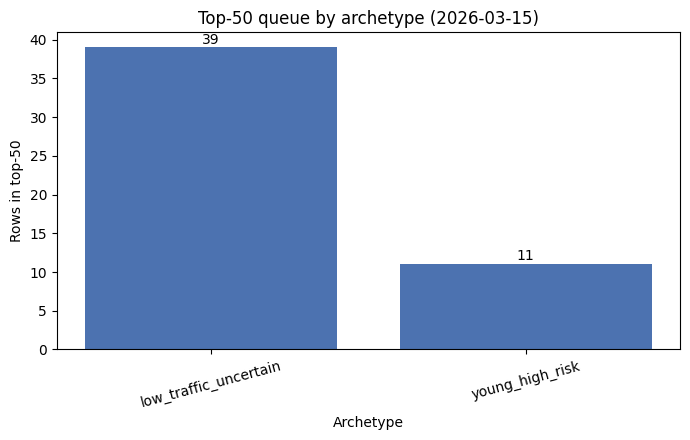

Saved work/figures/w07_archetype_distribution.png


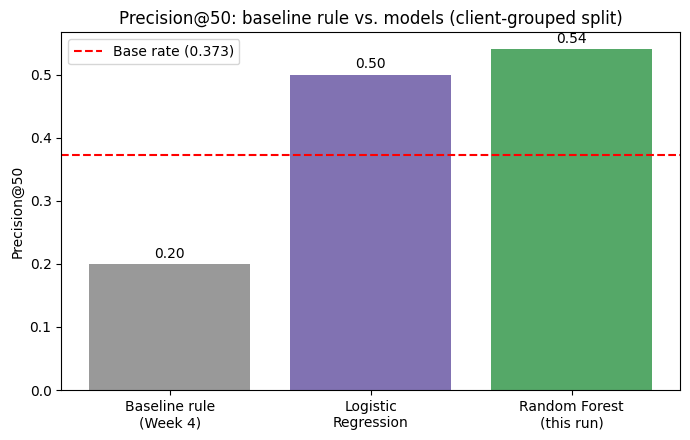

Saved work/figures/w07_precision_comparison.png


In [6]:
import json
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "work/outputs"
FIGURE_DIR = "work/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# --- 1. Ranked queue CSV (NOT committed -- CI leak-guard, notebook regenerates it) ---
export_cols = [
    'client_hash_id', 'content_hash_id', 'score_rf', 'archetype', 'action', 'reason_code',
    'pos_trailing', 'ctr_trailing', 'content_age_days', 'imp_trailing',
    # is_declining is deliberately EXCLUDED: it's the future outcome, not available at
    # decision time in real use. Keeping it here would misrepresent what the export looks
    # like in production.
]
export_queue = queue[export_cols].reset_index(drop=True)
queue_path = os.path.join(OUTPUT_DIR, "w07_ranked_action_queue.csv")
export_queue.to_csv(queue_path, index=False)
print(f"Wrote {len(export_queue)} rows to {queue_path}")

# --- 2. Metrics JSON (committed -- the paper's numbers trace back to this) ---
metrics_export = {
    "decision_day": DECISION_DAY,
    "model_config": "RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42)",
    "precision_at_50": round(p_at_k, 3),
    "test_base_rate": round(test_df['is_declining'].mean(), 3),
    "n_test_rows": int(len(test_df)),
    "n_test_clients": int(test_df['client_hash_id'].nunique()),
    "n_scored_population_clients": int(scored['client_hash_id'].nunique()),
    "reliability_floor_impressions": RELIABILITY_FLOOR,
    "share_below_reliability_floor_top50": round((queue['imp_trailing'] < RELIABILITY_FLOOR).mean(), 3),
    "archetype_share_top50": queue['archetype'].value_counts(normalize=True).round(3).to_dict(),
    "archetype_precision_top50": queue.groupby('archetype')['is_declining'].mean().round(3).to_dict(),
    "top_feature": "content_age_days",
    "top_feature_gini_importance": 0.405,
    "retrain_triggers": retrain_triggers,
}
metrics_path = os.path.join(OUTPUT_DIR, "w07_playbook_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_export, f, indent=2)
print(f"Wrote metrics to {metrics_path}")

# --- 3. Figure 1: archetype distribution in top-50 (committed) ---
archetype_counts = queue['archetype'].value_counts()
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.bar(archetype_counts.index, archetype_counts.values, color="#4C72B0")
ax1.set_title(f"Top-50 queue by archetype ({DECISION_DAY})")
ax1.set_ylabel("Rows in top-50")
ax1.set_xlabel("Archetype")
for i, v in enumerate(archetype_counts.values):
    ax1.text(i, v + 0.5, str(v), ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
fig1_path = os.path.join(FIGURE_DIR, "w07_archetype_distribution.png")
plt.savefig(fig1_path, dpi=150)
plt.show()
print(f"Saved {fig1_path}")

# --- 4. Figure 2: precision@50 comparison (Week-5 numbers, reused for the paper) ---
comparison_data = {
    "Baseline rule\n(Week 4)": 0.20,
    "Logistic\nRegression": 0.50,
    "Random Forest\n(this run)": round(p_at_k, 3),
}
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
bars = ax2.bar(comparison_data.keys(), comparison_data.values(), color=["#999999", "#8172B2", "#55A868"])
ax2.axhline(test_df['is_declining'].mean(), color="red", linestyle="--", label=f"Base rate ({test_df['is_declining'].mean():.3f})")
ax2.set_ylabel("Precision@50")
ax2.set_title("Precision@50: baseline rule vs. models (client-grouped split)")
ax2.legend()
for bar, val in zip(bars, comparison_data.values()):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.2f}", ha='center')
plt.tight_layout()
fig2_path = os.path.join(FIGURE_DIR, "w07_precision_comparison.png")
plt.savefig(fig2_path, dpi=150)
plt.show()
print(f"Saved {fig2_path}")

Three artifacts, two different commit rules:

- **`work/outputs/w07_ranked_action_queue.csv`** — the top-50 with archetype, action, reason
  code. Excludes `is_declining` deliberately: in real use this column doesn't exist yet at
  decision time, so keeping it here would misrepresent the production shape of this export.
  Stays out of git (CI leak-guard) — the notebook regenerates it on every run.
- **`work/outputs/w07_playbook_metrics.json`** — every number this playbook's claims rest on
  (precision@50, base rate, archetype shares, retrain triggers). Committed — this is what the
  paper's numbers trace back to.
- **`work/figures/w07_archetype_distribution.png`** and **`w07_precision_comparison.png`** —
  committed, reused directly in the paper's recommendations section.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.